In [1]:
using Pkg
ENV["JULIA_REVISE_POLL"]="1"
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
using Revise

  Activating project at `~/Github_Projects/JJDFTX.jl`


In [3]:
using PyPlot, PyCall, JJDFTX, LinearAlgebra
interpolate = pyimport("scipy.interpolate").interp1d;
using JJDFTX: fermi, bose

In [5]:
Hwannier, cell_map = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");

In [7]:
Es, Ds = density_of_states(Hwannier, cell_map, Val(2), mesh=30, num_blocks=500, monte_carlo=true, histogram_width=100)

([-3.798615570860458, -3.7886212642364385, -3.7786269576124196, -3.7686326509884003, -3.7586383443643814, -3.748644037740362, -3.738649731116343, -3.728655424492324, -3.718661117868305, -3.7086668112442855  …  -1.0102040227591154, -1.0002097161350965, -0.9902154095110771, -0.9802211028870578, -0.9702267962630389, -0.9602324896390195, -0.9502381830150006, -0.9402438763909813, -0.9302495697669624, -0.920255263142943], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

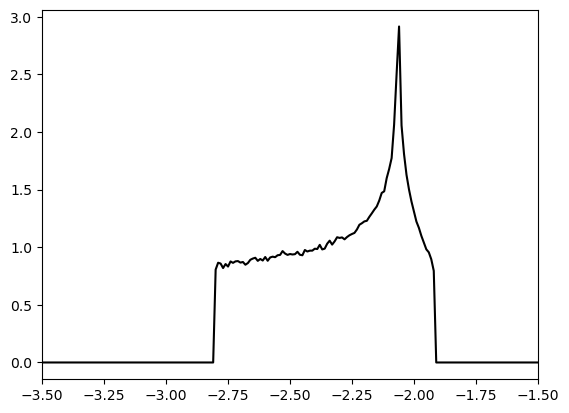

In [8]:
plot(Es, Ds, color="black")
xlim(-3.5, -1.5);

### First load the density of states

In [9]:
dos_dir = "./dos_from_wannier/";
mus = [-2.6892471879135815, -2.5793095160429926, -2.4693718441724037, -2.369428506108232, -2.26948516804406];

In [10]:
N = 100
Ds_totals = [zeros(4*N) for i in 1:5]
Es_total = collect(range(-2, 2, length=4*N))
for id in 1:200
    Es, Ds = [x for x in eachcol(np.loadtxt(dos_dir * "./dos-$id.txt"))]
    for mu_idx in 1:5
        for (e_idx, e) in enumerate(Es_total)
            Ds_totals[mu_idx][e_idx] += Ds[argmin(abs.(e .- (Es .- mus[mu_idx])))]
        end
    end
end
Ds_totals *= 1/200;

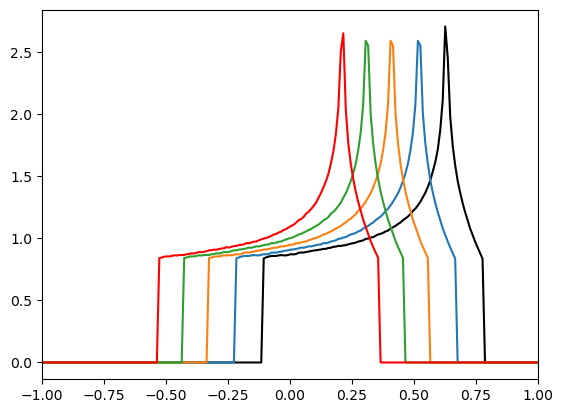

In [13]:
plot(Es_total, Ds_totals[1], color="black")
plot(Es_total, Ds_totals[2])
plot(Es_total, Ds_totals[3])
plot(Es_total, Ds_totals[4])
plot(Es_total, Ds_totals[5], color="red")
xlim(-1, 1);

In [14]:
sigmas_mu = []
sigmas_mu_from_dos = []
meshing = 3
histogram_width = 10
for mu_idx in 1:5
    x = 0
    y = zeros(400)
    for i in 1:200
        b = np.loadtxt("./self_energy/self_energy-muidx$(mu_idx)-$i.txt")[:, 1]
        a = np.loadtxt("./self_energy/self_energy-nums-muidx$(mu_idx)-$i.txt")[1]
        y += b
        x += a 
    end
    sigmas_dos = y / (200 * Ds_totals[mu_idx][200]*meshing^2/histogram_width)
    sigmas = y ./ x;
    push!(sigmas_mu, sigmas)
    push!(sigmas_mu_from_dos, sigmas_dos)
end

### Compare the meshing from the self energy calculations to the DOS calculated 

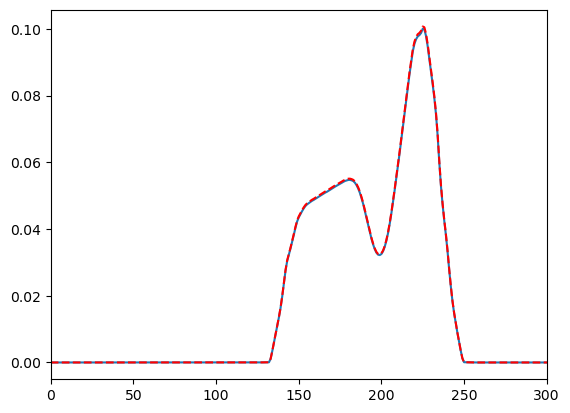

In [15]:
plot(sigmas_mu[5])
plot(sigmas_mu_from_dos[5], color="red", linestyle="dashed")
xlim(0, 300);

In [18]:
fracroom = 1 # Room temperature
omegas = collect(range(-2, 2, length=400));
N = 100 
fomegas = JJDFTX.fermi.(omegas, fracroom);
tau_invs_mu = []
taus_mu = []
max_freq = 2
for mu_idx in 1:5
    sigmas = sigmas_mu[mu_idx]
    tau_invs = zeros(Int(max_freq*100))
    for (i, omega) in enumerate(range(0.01, max_freq, length=Int(max_freq*100)))
        fomegaprimes = JJDFTX.fermi.(omegas .+ omega, fracroom);
        omega_idx = round(Int, omega * N)
        tau_inv = 0
        for idx in 1:(4*N-omega_idx)
            tau_inv += omega * (1/N) * (fomegaprimes[idx] - fomegas[idx])*imag(1/(1im*sigmas[idx]+1im*sigmas[idx+omega_idx]+omega))
        end
        tau_invs[i] = tau_inv
    end
    push!(tau_invs_mu, tau_invs)
    push!(taus_mu, (10^15)*(ħ ./ tau_invs))
end

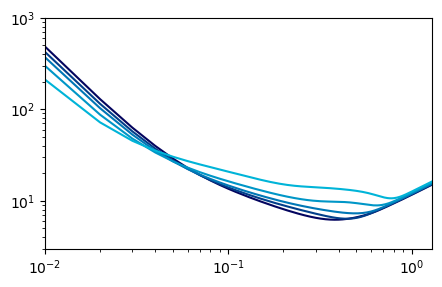

In [19]:
figure(figsize=(5, 3))
Nprime = 200 
win_len = 1
loglog(range(0.01, max_freq, length=Nprime), smooth(taus_mu[5], win_len=win_len), color="#03045E")
loglog(range(0.01, max_freq, length=Nprime), smooth(taus_mu[4], win_len=win_len), color="#023E8A")
loglog(range(0.01, max_freq, length=Nprime), smooth(taus_mu[3], win_len=win_len),  color="#0077B6")
loglog(range(0.01, max_freq, length=Nprime), smooth(taus_mu[2], win_len=win_len), color="#0096C7")
loglog(range(0.01, max_freq, length=Nprime), smooth(taus_mu[1], win_len=win_len), color="#00B4D8")
ylim(3, 10^3)
xlim(0.01, 1.3);
#savefig("Scattering_Comparison_fixed_dos.pdf")

### Decay time from Allen's approach 

In [20]:
tau_allen_mus = []
for mu_idx in 1:5
    tau_allen_inv = zeros(130)
    N = 160
    for i in 1:N
        tau_allen_inv += 1 ./ np.loadtxt("tau/tau-muidx$(mu_idx).out-$i")
    end
    tau_allen_inv *= 1/N 
    tau_allen = 1 ./ tau_allen_inv;
    push!(tau_allen_mus, tau_allen)
end

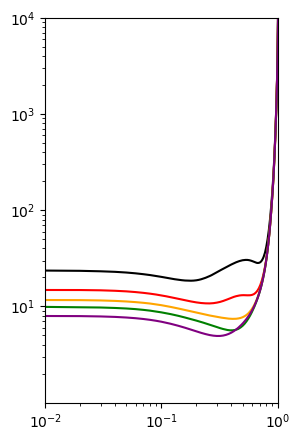

In [21]:
cm=1/2.54
#figure(figsize=(3cm, 5cm))
figure(figsize=(3, 5))
loglog(0.01:0.01:1.3, tau_allen_mus[1], color="black")
loglog(0.01:0.01:1.3, tau_allen_mus[2], color="red")
loglog(0.01:0.01:1.3, tau_allen_mus[3], color="orange")
loglog(0.01:0.01:1.3, tau_allen_mus[4], color="green")
loglog(0.01:0.01:1.3, tau_allen_mus[5], color="purple")
yticks([10, 100, 1000, 10000])
xlim(0.01, 1)
ylim(1, 10000);
#savefig("tau.pdf")

In [22]:
self_energies_mu = []
totals_mu = []
for mu_idx in 1:2
    println("mu_idx: ", mu_idx); flush(stdout); 
    total = zeros(400)
    new_self_energy = zeros(400, 400)
    for i in 1:200
        b = np.loadtxt("./self_energy_2/self_energy-muidx$(mu_idx)-$i.txt")
        a = np.loadtxt("./self_energy_2/self_energy-muidx$(mu_idx)-nums-$i.txt")
        total += a
        new_self_energy += b
    end
    push!(self_energies_mu, replace(new_self_energy ./ np.repeat(np.reshape(total, (400, 1)), 400, axis=1), NaN=>0))
    push!(totals_mu, total)
end

mu_idx: 1
mu_idx: 2


In [24]:
N = 100 #1000
Nprime = 100
plot_len = 100
delta = 0
omegas3 = collect(range(-2, 2, length=4*N));
omegas4 = collect(range(-2, 2, length=4*Nprime));
fomegas = fermi.(omegas3, 1);
tau_invs3_mus = []

for mu_idx in 1:2
    println("mu_idx: $mu_idx"); flush(stdout); 
    self_energy = self_energies_mu[mu_idx]
    total = totals_mu[mu_idx]
    tau_invs3 = zeros(plot_len)
    win_len = 1
    for (i, omega) in enumerate(range(0.01, 1.16, length=plot_len))
        fomegaprimes = fermi.(omegas3 .+ omega, 1);
        omega_idx = round(Int, omega * N)
        tau_inv = 0
        for idx2 in 1:length(omegas4)
            epsilon = omegas4[idx2]
            self_energy_idx = argmin(abs.(epsilon .- omegas3))
            self_energy_epsilon = smooth(self_energy[self_energy_idx, :], win_len=win_len)
            dos_term = total[self_energy_idx] / total[200]
            iszero(dos_term) && continue
            for idx in 1:(4*N-omega_idx)
                omegaprime = omegas3[idx]
                A1 = imag(1/(omega+omegaprime-epsilon+1im*delta+1im*self_energy_epsilon[idx+omega_idx]))
                A2 = imag(1/(omegaprime-epsilon+1im*delta+1im*self_energy_epsilon[idx]))
                tau_inv += dos_term * (omega/pi) * (1/Nprime)*(1/N) * (-fomegaprimes[idx] + fomegas[idx])*A1*A2
            end
        end
        tau_invs3[i] = tau_inv
    end
    push!(tau_invs3_mus, tau_invs3)
end
taus3_mus = [(10^15)*(ħ ./ tau_invs3) for tau_invs3 in tau_invs3_mus];

mu_idx: 1
mu_idx: 2


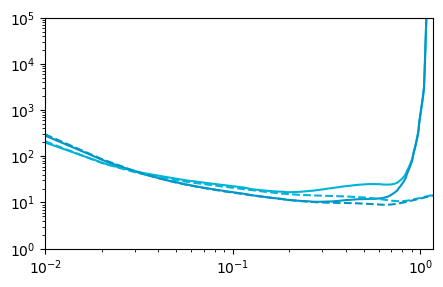

In [25]:
figure(figsize=(5, 3))
win_len = 1
ls1 = "solid"
ls2 = "dashed"
max_freq = 2
loglog(range(0.01, 1.16, length=plot_len), smooth(taus3_mus[1], win_len=win_len), color="#00B4D8", linestyle=ls1)
loglog(range(0.01, 1.16, length=plot_len), smooth(taus3_mus[2], win_len=win_len), color="#0096C7", linestyle=ls1)
#loglog(range(0.01, 1.16, length=plot_len), smooth(taus3_mus[3], win_len=win_len), color="#0077B6", linestyle=ls1)
#loglog(range(0.01, 1.16, length=plot_len), smooth(taus3_mus[4], win_len=win_len), color="#023E8A", linestyle=ls1)
#loglog(range(0.01, 1.16, length=plot_len), smooth(taus3_mus[5], win_len=win_len), color="#03045E", linestyle=ls1)

loglog(range(0.01, max_freq, length=200), smooth(taus_mu[1], win_len=win_len), color="#00B4D8", linestyle=ls2)
loglog(range(0.01,max_freq, length=200), smooth(taus_mu[2], win_len=win_len), color="#0096C7", linestyle=ls2)
#loglog(range(0.01, max_freq, length=Nprime), smooth(taus_mu[3], win_len=win_len),  color="#0077B6", linestyle=ls2)
#loglog(range(0.01, max_freq, length=Nprime), smooth(taus_mu[4], win_len=win_len),  color="#023E8A", linestyle=ls2)
#loglog(range(0.01, max_freq, length=Nprime), smooth(taus_mu[5], win_len=win_len), color="#03045E",linestyle=ls2)

ylim(1, 10^5)
xlim(0.01, 1.16);
#savefig("Scattering_Comparison2-fixed-dos.pdf")